In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [10]:
try:
    df = pd.read_csv('/content/Mall_Customers.csv')
    print('Dataset loaded from /content/Mall_Customers.csv')

except FileNotFoundError:
    rng = np.random.default_rng(42)
    df = pd.DataFrame({
        'CustomerID': np.arange(1, 201),
        'Gender': rng.choice(['Male', 'Female'], size=200),
        'Age': np.clip(rng.normal(38, 12, size=200).round(), 18, 70),
        'Annual Income (k$)': np.clip(rng.normal(60, 22, size=200), 15, 140),
        'Spending Score (1-100)': np.clip(rng.normal(50, 25, size=200), 1, 99)
    })
    print('Synthetic fallback dataset created')

df.head()

Synthetic fallback dataset created


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,43.0,21.352121,1.000000
1,2,Female,27.0,67.215901,12.623479
2,3,Female,33.0,98.001705,84.096556
3,4,Male,54.0,26.255049,72.379625
4,5,Male,34.0,79.004216,32.012994


In [11]:
print('Shape of dataset:', df.shape)

print('\nColumn names:')
print(df.columns.tolist())

print('\nMissing values:')
print(df.isnull().sum())

print('\nDataset info:')
df.info()

Shape of dataset: (200, 5)

Column names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    object 
 2   Age                     200 non-null    float64
 3   Annual Income (k$)      200 non-null    float64
 4   Spending Score (1-100)  200 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 7.9+ KB


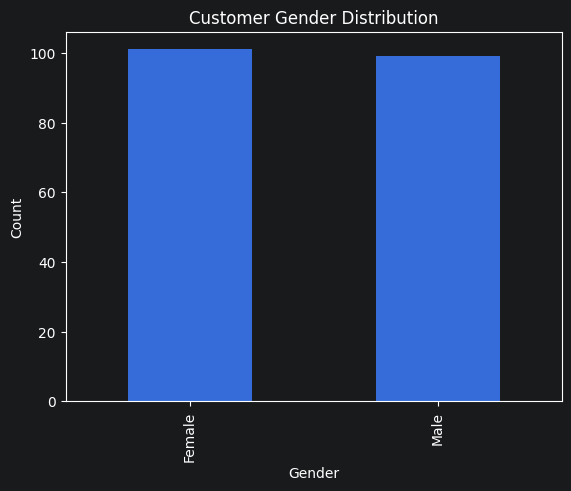

In [12]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

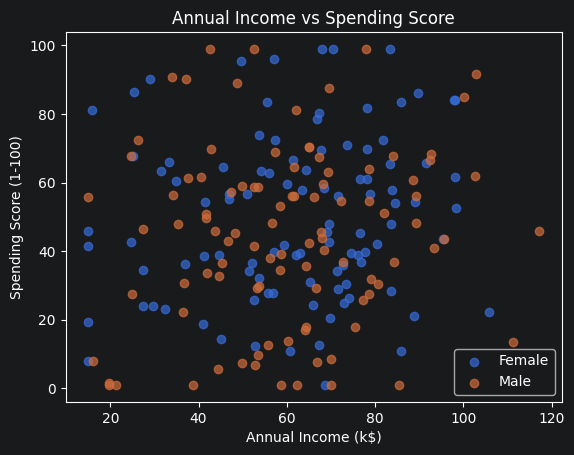

In [13]:
for g, grp in df.groupby('Gender'):
    plt.scatter(grp['Annual Income (k$)'],
                grp['Spending Score (1-100)'],
                label=g, alpha=0.7)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

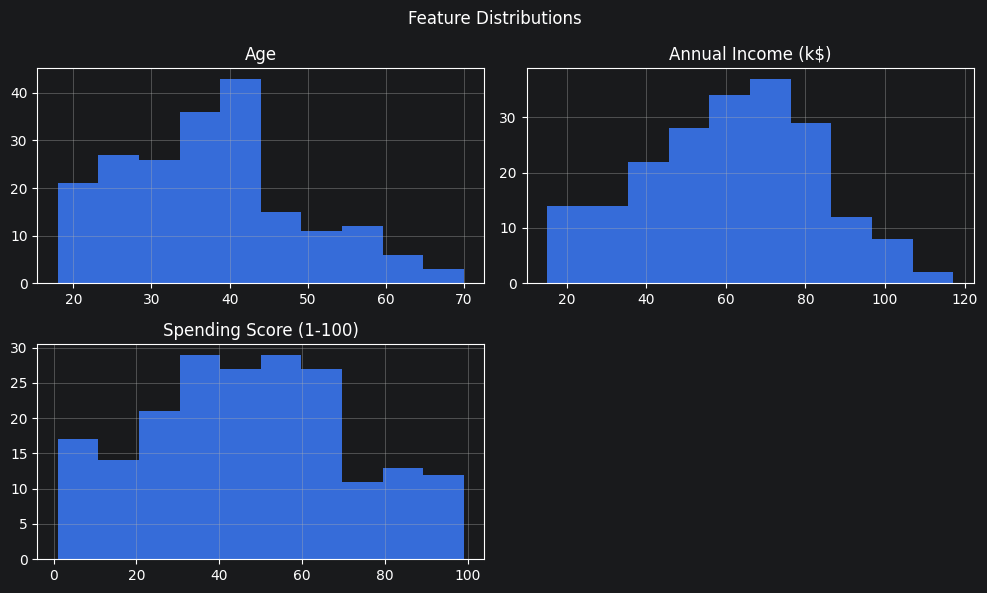

In [14]:
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].hist(figsize=(10, 6))
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

In [15]:
if 'CustomerID' in df.columns:
    df.drop(columns=['CustomerID'], inplace=True)

if 'Gender' in df.columns:
    df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

imputer = SimpleImputer(strategy='median')
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] = imputer.fit_transform(
    df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
)

In [16]:
selected_features = ['Annual Income (k$)', 'Spending Score (1-100)']

X = df[selected_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
print('Selected Features for Clustering:')
for feature in selected_features:
    print('-', feature)

Selected Features for Clustering:
- Annual Income (k$)
- Spending Score (1-100)


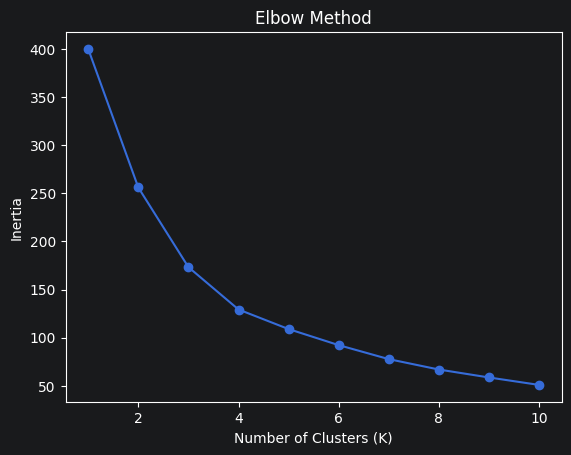

In [18]:
inertias = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [19]:
model = KMeans(n_clusters=5, n_init=10, random_state=42)
clusters = model.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df[['Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head())

   Annual Income (k$)  Spending Score (1-100)  Cluster
0           21.352121                1.000000        3
1           67.215901               12.623479        0
2           98.001705               84.096556        1
3           26.255049               72.379625        2
4           79.004216               32.012994        0


Silhouette Score: 0.33538986189999404


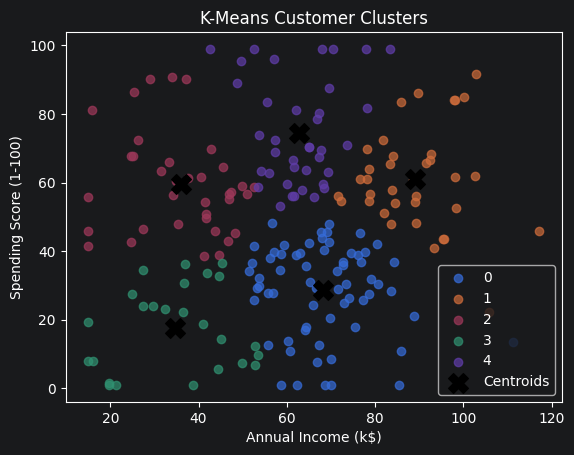

In [20]:
sil_score = silhouette_score(X_scaled, clusters)
print('Silhouette Score:', sil_score)

centers = scaler.inverse_transform(model.cluster_centers_)

for c, grp in df.groupby('Cluster'):
    plt.scatter(grp['Annual Income (k$)'],
                grp['Spending Score (1-100)'],
                label=c, alpha=0.7)

plt.scatter(centers[:, 0], centers[:, 1],
            s=200, c='black', marker='X', label='Centroids')

plt.title('K-Means Customer Clusters')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()